In [ ]:
global_var = 10


def create_system(o_num, o_def_num=100, o_def_list=[]):
    o_str = "Start"
    o_list = ["Loc"]

    def inner(i_num, i_def_num=200, i_def_list=[]):
        nonlocal o_str, o_def_num
        global global_var

        # Mutations
        o_def_list.append(o_num)
        o_list.append("M")
        i_def_list.append(i_num)

        # Reassignments
        o_str += "!"
        o_def_num += 1
        global_var += 1

        return {
            "o_str": o_str,
            "o_list": o_list,
            "o_def_list": o_def_list,
            "o_def_num": o_def_num,
            "i_def_list": i_def_list,
            "global_var": global_var,
        }

    traps = []
    for i in range(3):

        def loop_trap():
            return i

        traps.append(loop_trap)

    return inner, traps


# --- THE EXECUTION PHASE ---

# 1. Create the functions (Two separate outer calls)
inner_A1, traps_A = create_system(1)
inner_B1, traps_B = create_system(2)

# 2. Execute the inner functions
res1 = inner_A1(10)
res2 = inner_A1(20)
res3 = inner_B1(30)

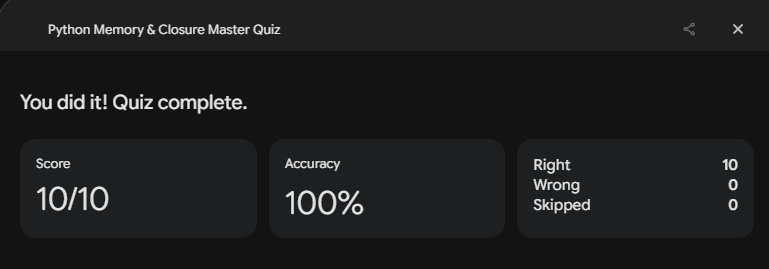


The Final Exam: Questions & Explanations
Question 1: Look at res1. After inner_A1(10) runs for the first time, what is the value of res1["o_def_list"]?

Correct Answer: [1]

Explanation: Because o_def_list is an outer default mutable, it is created exactly once when the script runs. It starts empty. inner_A1 looks through its Glass Box, finds the list, and appends o_num (which was 1 from the first stack frame).

Question 2: Look at res2. After inner_A1(20) runs (the second call to the SAME function object), what is the value of res2["o_def_list"]?

Correct Answer: [1, 1]

Explanation: The closure points to the shared outer default list in the Heap. Because we called inner_A1 again, it looks at its outer parameter o_num (which is still permanently 1 for this specific function) and appends it a second time.

Question 3: Now look at res3. We execute inner_B1(30), which was created from a completely different outer call. What is the value of res3["o_def_list"]?

Correct Answer: [1, 1, 2]

Explanation: Because o_def_list is an outer default mutable, both inner_A1 and inner_B1 point to the exact same list in the Heap. inner_B1 appends its own outer parameter o_num (which is 2).

Question 4: Let's check the inner defaults. What is the value of res2["i_def_list"]?

Correct Answer: [10, 20]

Explanation: Because res1 and res2 are both executions of the exact same inner_A1 function object, they share the inner default list that was created specifically when inner_A1 was defined. It appends the inner parameter i_num (10, then 20).

Question 5: What is the value of res3["i_def_list"]?

Correct Answer: [30]

Explanation: When create_system(2) ran, it executed the def inner... command a second time. Python built a brand new, isolated inner default list just for inner_B1. It completely ignores inner_A1's list and just appends 30.

Question 6: Let's check the outer local variables. What is the value of res2["o_str"]?

Correct Answer: 'Start!!'

Explanation: Because res1 and res2 use the same inner_A1 closure, they are using nonlocal to cross out and rewrite the sticky note inside the exact same shared Glass Box.

Question 7: What is the value of res3["o_str"]?

Correct Answer: 'Start!'

Explanation: Every time the outer function runs, outer local variables are created fresh. inner_B1 has its own completely isolated closure cell (Glass Box) for o_str, generated during the second outer call. It starts fresh at "Start" and adds one "!".

Question 8 (The Broken Link): What is the value of res3["o_def_num"]?

Correct Answer: 101

Explanation: Both inner_A1 and inner_B1 started pointing to the cached default integer 100. inner_A1 used nonlocal to break its link, crossing out 100 and pointing to 102 (across its two calls). But inner_B1's cell was untouched! It still pointed to the original 100, so when it ran, it changed its cell to point to 101.

Question 9 (The Late Binding Loop Gotcha): What does traps_A[0]() return?

Correct Answer: 2

Explanation: All three loop trap functions share a map to the exact same Glass Box for the variable i. When the loop finishes, the sticky note inside that Glass Box says 2. When you finally call the function, it looks in the box and returns 2.

Question 10: Finally, the global variable. After res1, res2, and res3 have all run, what is the value of global_var?

Correct Answer: 13

Explanation: The global keyword bypasses closure cells entirely and points directly to the module-level variable. The inner function executed three times in total across the script (res1, res2, res3). 10 + 3 = 13.